In [1]:
import pandas as pd
import numpy as np

In [2]:
import statsmodels.api as sm 
from statsmodels.formula.api import ols
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

In [4]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'

In [5]:
df = pd.read_excel(fpath + '\\4.0_database_variables.xlsx')

In [6]:
df = df.rename(columns={'location(ita=0,uk=1,usa=2)': 'location', 'weekday(1=free days)': 'weekday'})

In [7]:
# remove outliers
df = df[(np.abs(stats.zscore(df['sleep_duration(h)'])) < 3)]
df = df[(np.abs(stats.zscore(df['midpoint_h'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_start_decimal'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_end_decimal'])) < 3)]
df = df[(np.abs(stats.zscore(df['phase(sleepoffset-sunrise)'])) < 3)]

In [8]:
df = df.drop('sunrise_time(USA)', axis=1)

In [9]:
df = df.drop('sunrise (USA), hours', axis=1)

In [10]:
df = df.drop('sunset (USA), hours', axis=1)

In [11]:
df = df.drop('sunset_time(USA)', axis=1)

In [12]:
df = df.drop('photoperiod (h, USA)', axis=1)

In [13]:
# Define the start date
start_date = pd.to_datetime('2022-09-21')

In [14]:
# Function to calculate the week of the year from the start date
def calculate_week_of_year(date):
    year_diff = date.year - start_date.year
    start_of_year = pd.to_datetime(f'{date.year}-01-01')
    weeks_from_start = ((date - start_of_year).days // 7) + 1
    return year_diff * 52 + weeks_from_start

# Apply the function to calculate the week of the year
df['week_of_year'] = df['date'].apply(calculate_week_of_year)

In [15]:
# adjust 'week of the year' to start from 0
df['week_of_year'] = df['week_of_year'] - 37

In [16]:
#rename the location column as 0=ITA, 1=UK
df['location'] = df['location'].map({0: 'ITA', 1: 'UK'})

#rename the weekday column as 0=work days, 1=free days
df['weekday'] = df['weekday'].map({0: 'work days', 1: 'free days'})

# Descriptive analysis

In [17]:
all_descriptive = df.describe()
all_descriptive = all_descriptive.transpose()

In [18]:
#test normality of the data using Shapiro-Wilk test 
#H0: data is normally distributed
shapiro_test_sleep_duration = stats.shapiro(df['sleep_duration(h)'])
shapiro_test_midpoint = stats.shapiro(df['midpoint_h'])
shapiro_test_sleep_start = stats.shapiro(df['sleep_start_decimal'])
shapiro_test_sleep_end = stats.shapiro(df['sleep_end_decimal'])
shapiro_test_phase = stats.shapiro(df['phase(sleepoffset-sunrise)'])

In [19]:
shapiro_results_descriptive = pd.DataFrame({
    'Variable': ['sleep_duration(h)', 'midpoint_h', 'sleep_start_decimal', 'sleep_end_decimal', 'phase(sleepoffset-sunrise)'],
    'Shapiro-Wilk test': [shapiro_test_sleep_duration, shapiro_test_midpoint, shapiro_test_sleep_start, shapiro_test_sleep_end, shapiro_test_phase]
})

In [20]:
shapiro_results_descriptive

,Variable,Shapiro-Wilk test
0,sleep_duration(h),"(0.9902568788231293, 0.0008572700408180585)"
1,midpoint_h,"(0.9953842221350677, 0.09176026856174113)"
2,sleep_start_decimal,"(0.9933031110054771, 0.012890058203709061)"
3,sleep_end_decimal,"(0.8910493382471318, 1.4676570099459215e-19)"
4,phase(sleepoffset-sunrise),"(0.9644101411394511, 1.8415611196210638e-10)"


In [21]:
df_grouped_location = df.groupby('location').describe()
df_grouped_location = df_grouped_location.transpose()

In [22]:
df_grouped_weekday = df.groupby('weekday').describe()
df_grouped_weekday = df_grouped_weekday.transpose()

In [23]:
df_grouped_location_weekday = df.groupby(['location', 'weekday']).describe()
df_grouped_location_weekday = df_grouped_location_weekday.transpose()

In [24]:
# compare the midpoint, duration and phase between the two locations
ttest_midpoint_loc = stats.ttest_ind(df[df['location'] == 'ITA']['midpoint_h'], df[df['location'] == 'UK']['midpoint_h'])
utest_duration_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_duration(h)'], df[df['location'] == 'UK']['sleep_duration(h)'])
utest_phase_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['phase(sleepoffset-sunrise)'], df[df['location'] == 'UK']['phase(sleepoffset-sunrise)'])


#perform a t test to compare the midpoint, duration and phase between work days and free days
ttest_midpoint_week = stats.ttest_ind(df[df['weekday'] == 'work days']['midpoint_h'], df[df['weekday'] == 'free days']['midpoint_h'])
utest_duration_week = stats.mannwhitneyu(df[df['weekday'] == 'work days']['sleep_duration(h)'], df[df['weekday'] == 'free days']['sleep_duration(h)'])
utest_phase_week = stats.mannwhitneyu(df[df['weekday'] == 'work days']['phase(sleepoffset-sunrise)'], df[df['weekday'] == 'free days']['phase(sleepoffset-sunrise)'])

In [ ]:
print('Results for location')
print('Midpoint:', ttest_midpoint_loc)
print('Duration:', utest_duration_loc)
print('Phase:', utest_phase_loc)

Results for location
Midpoint: TtestResult(statistic=2.6805139423138473, pvalue=0.0075662781488848386, df=563.0)
Duration: MannwhitneyuResult(statistic=37319.5, pvalue=0.5273231488217915)
Phase: MannwhitneyuResult(statistic=23106.0, pvalue=6.067805061758257e-16)


In [26]:
print('Results for weekday') 
print('Midpoint:', ttest_midpoint_week)
print('Duration:', utest_duration_week)
print('Phase:', utest_phase_week)

Results for weekday
Midpoint: TtestResult(statistic=-9.50032089200523, pvalue=5.939401753000896e-20, df=563.0)
Duration: MannwhitneyuResult(statistic=26278.5, pvalue=0.0015010629524126338)
Phase: MannwhitneyuResult(statistic=19999.5, pvalue=1.037493960895366e-11)


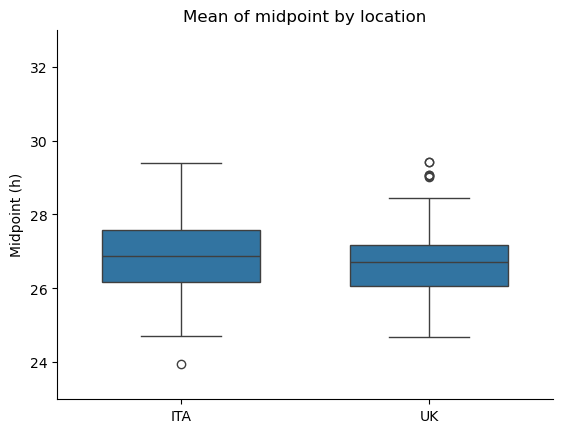

In [ ]:
plt.figure()
sns.boxplot(x='location', y='midpoint_h', data=df, gap=0.2)
plt.title('Mean of midpoint by location')
plt.xlabel('')
plt.ylim(23, 33)
plt.ylabel('Midpoint (h)')
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the left spine to black
plt.gca().spines['left'].set_color('black') 
plt.show()

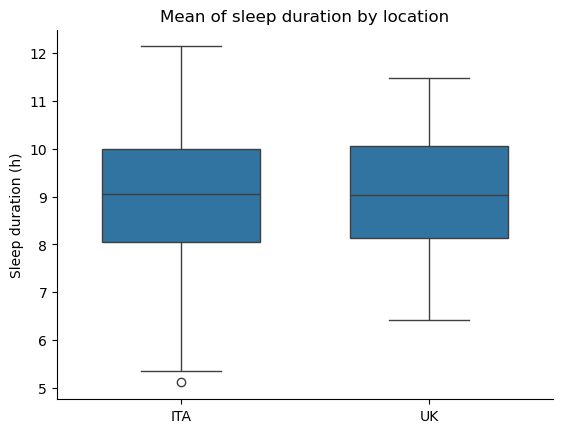

In [ ]:
plt.figure()
sns.boxplot(x='location', y='sleep_duration(h)', data=df, gap=0.2)
plt.title('Mean of sleep duration by location')
plt.xlabel('')
plt.ylabel('Sleep duration (h)')
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the x-axis to black
plt.gca().spines['left'].set_color('black')
plt.show()

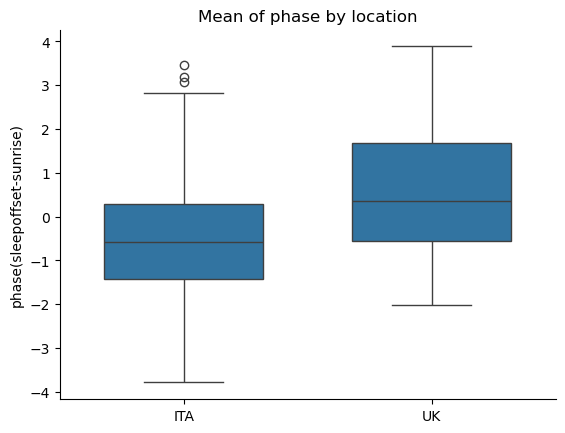

In [ ]:
plt.figure()
sns.boxplot(x='location', y='phase(sleepoffset-sunrise)', data=df, gap=0.2)
plt.title('Mean of phase by location')
plt.xlabel('')
plt.ylabel('phase(sleepoffset-sunrise)')
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the x-axis to black
plt.gca().spines['left'].set_color('black')
plt.show()

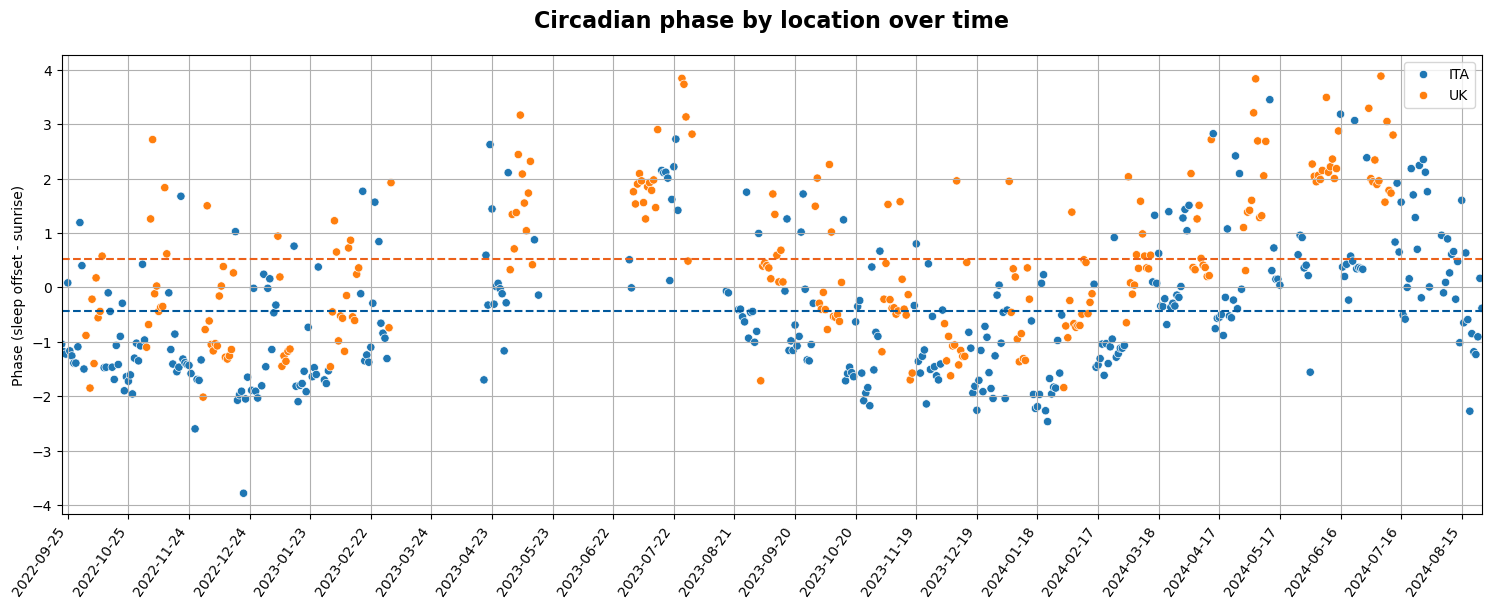

In [30]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='phase(sleepoffset-sunrise)', hue='location', data=df)
plt.title('Circadian phase by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (sleep offset - sunrise)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())

# get the current axes then set the x-axis major locator
# plot.gca()=ax if set ax = plt.gca()
plt.gca().xaxis.set_major_locator(MultipleLocator(30)) 

#add the mean of the phase for the two locations
plt.axhline(df[df['location'] == 'ITA']['phase(sleepoffset-sunrise)'].mean(), color='#00589c', linestyle='--', label='ITA mean')
plt.axhline(df[df['location'] == 'UK']['phase(sleepoffset-sunrise)'].mean(), color='#ec611a', linestyle='--', label='UK mean')

plt.show()

_Jetlag_

In [31]:
data_jetlag = df # create a new dataframe with the original data

In [32]:
# calculate the mean midpoint for each location, week and weekday
weekly_means_jetlag = data_jetlag.groupby(['location', 'week_of_year', 'weekday'])['midpoint_h'].mean().unstack()

In [33]:
weekly_means_jetlag['jet lag'] = weekly_means_jetlag['free days'] - weekly_means_jetlag['work days']

In [34]:
# add a column with the location
weekly_means_jetlag['location'] = weekly_means_jetlag.index.get_level_values(0)

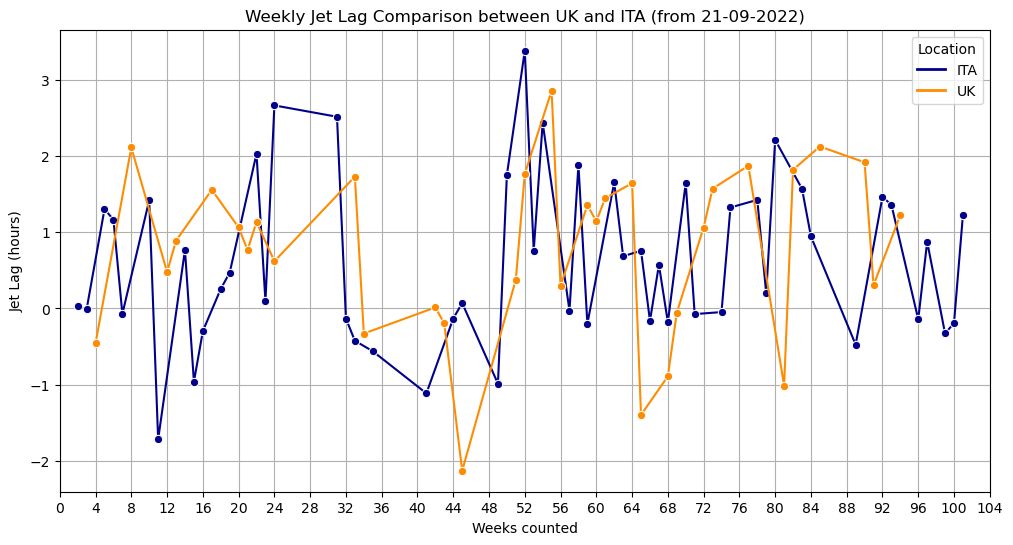

In [35]:
# Plot the weekly jet lag between UK and ITA
plt.figure(figsize=(12, 6))
sns.lineplot(x='week_of_year', y='jet lag', hue='location', data=weekly_means_jetlag, marker='o', palette=['darkblue', 'darkorange'])
plt.title('Weekly Jet Lag Comparison between UK and ITA (from 21-09-2022)')
plt.xlabel('Weeks counted')
plt.ylabel('Jet Lag (hours)')
plt.legend(title='Location', labels=['ITA', 'UK'], loc='upper right', handles=[plt.Line2D([0], [0], color='darkblue', lw=2), plt.Line2D([0], [0], color='darkorange', lw=2)])
plt.grid(True)
plt.xlim(0, 104)
plt.gca().xaxis.set_major_locator(MultipleLocator(4)) 
plt.xticks()
plt.show()

In [36]:
# Remove NaN values before performing the Shapiro-Wilk test
jetlag_no_nan = weekly_means_jetlag['jet lag'].dropna()

# Test normality of the jet lag data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_jetlag = stats.shapiro(jetlag_no_nan)


In [37]:
shapiro_test_jetlag

ShapiroResult(statistic=0.9886062153387764, pvalue=0.6513971208853703)

In [38]:
# Perform a t-test to compare the jet lag between the two locations
ttest_jetlag = stats.ttest_ind(weekly_means_jetlag[weekly_means_jetlag['location'] == 'ITA']['jet lag'].dropna(), weekly_means_jetlag[weekly_means_jetlag['location'] == 'UK']['jet lag'].dropna())

print('Results for jet lag:')
print(ttest_jetlag)

Results for jet lag:
TtestResult(statistic=-0.6990671681442698, pvalue=0.48641855739690765, df=85.0)


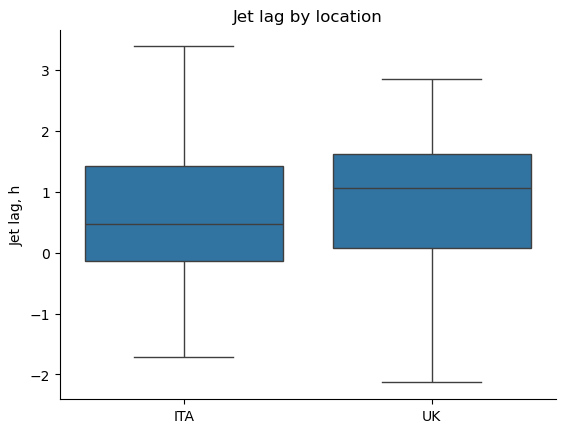

In [39]:
#plot the jet lag
plt.figure()
sns.boxplot(x='location', y='jet lag', data=weekly_means_jetlag)
plt.title('Jet lag by location')
plt.xlabel('')
plt.ylabel('Jet lag, h')

sns.despine()
plt.grid(False)
#bottom and left spine black
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')

plt.show()

_Seasonal effect_

In [40]:
df = df.rename(columns={'sleep_duration(h)': 'sleep_duration'})

In [41]:
df = df.rename(columns={'phase(sleepoffset-sunrise)': 'phase'})

In [42]:
# Adding a 'season' column to the dataset based on the 'date' column
# Defining seasons based on months: 
# Winter (Dec-Feb), Spring (Mar-May), Summer (Jun-Aug), Autumn (Sep-Nov)

def assign_season(date):
    month = pd.to_datetime(date).month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

In [43]:
# Applying the function to create a season column
df['season'] = df['date'].apply(assign_season)

<Figure size 1200x600 with 0 Axes>

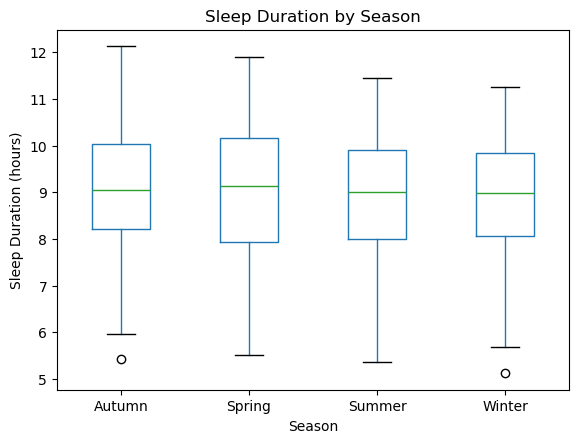

In [44]:
# Plot 1: Sleep Duration by Season
plt.figure(figsize=(12, 6))
df.boxplot(column='sleep_duration', by='season', grid=False)
plt.title('Sleep Duration by Season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Sleep Duration (hours)')
plt.xlabel('Season')
plt.show()

<Figure size 1200x600 with 0 Axes>

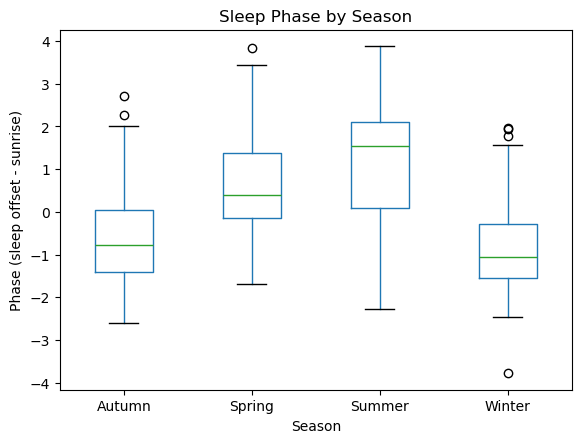

In [45]:
# Plot 2: Sleep Phase by Season
plt.figure(figsize=(12, 6))
df.boxplot(column='phase', by='season', grid=False)
plt.title('Sleep Phase by Season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Phase (sleep offset - sunrise)')
plt.xlabel('Season')
plt.show()

<Figure size 1200x600 with 0 Axes>

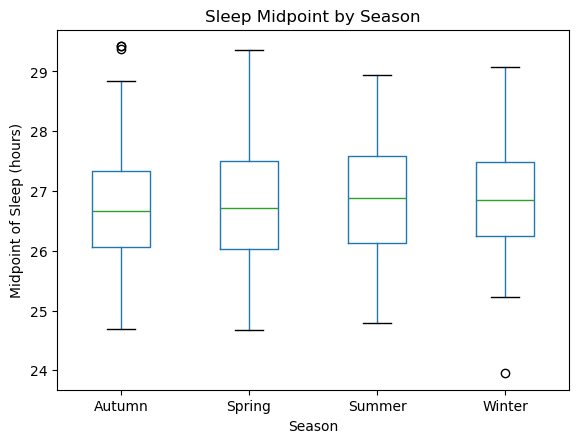

In [46]:
# Plot 3: Sleep Midpoint (midpoint_h) by Season
plt.figure(figsize=(12, 6))
df.boxplot(column='midpoint_h', by='season', grid=False)
plt.title('Sleep Midpoint by Season')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Midpoint of Sleep (hours)')
plt.xlabel('Season')
plt.show()

In [47]:
df = df.dropna(subset=['sleep_duration'])
df = df.dropna(subset=['phase'])

In [48]:
anova_midpoint_season1 = ols('midpoint_h ~ C(season)', data=df).fit()

In [49]:
# Summarizing ANOVA results for each variable
anova_midpoint_result_season = sm.stats.anova_lm(anova_midpoint_season1, typ=3)

In [50]:
print("\nANOVA_midpoint Results:")
print(anova_midpoint_result_season)


ANOVA_midpoint Results:
                  sum_sq     df              F    PR(>F)
Intercept  113451.215313    1.0  134109.424151  0.000000
C(season)       3.155630    3.0       1.243412  0.293186
Residual      474.583589  561.0            NaN       NaN


In [51]:
# expand the results of the Kruskal-Wallis test TO HAVE DF and p-value and not just the test statistic
kw_sleep_duration_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_duration'], df[df['season'] == 'Spring']['sleep_duration'], df[df['season'] == 'Summer']['sleep_duration'], df[df['season'] == 'Autumn']['sleep_duration'])
kw_phase_season = stats.kruskal(df[df['season'] == 'Winter']['phase'], df[df['season'] == 'Spring']['phase'], df[df['season'] == 'Summer']['phase'], df[df['season'] == 'Autumn']['phase'])

# Print the results of the Kruskal-Wallis test
print('Results for Kruskal-Wallis test for the sleep duration by season')
print(kw_sleep_duration_season)
print('Results for Kruskal-Wallis test for the phase by season')
print(kw_phase_season)


Results for Kruskal-Wallis test for the sleep duration by season
KruskalResult(statistic=1.5890340956216034, pvalue=0.6618788132777524)
Results for Kruskal-Wallis test for the phase by season
KruskalResult(statistic=203.3077922242939, pvalue=8.136011047815583e-44)


In [52]:
# Perform a Tukey HSD test to compare the means 
tukey_results = pairwise_tukeyhsd(df['sleep_duration'], df['season'])
print(tukey_results)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Autumn Spring   0.0187 0.9994 -0.3899 0.4273  False
Autumn Summer  -0.1612 0.7337 -0.5657 0.2433  False
Autumn Winter  -0.1025  0.888 -0.4677 0.2628  False
Spring Summer  -0.1799 0.7139 -0.6171 0.2573  False
Spring Winter  -0.1211 0.8644 -0.5223   0.28  False
Summer Winter   0.0588 0.9811 -0.3383 0.4558  False
---------------------------------------------------


In [53]:
# Perform a Tukey HSD test to compare the means
tukey_results = pairwise_tukeyhsd(df['phase'], df['season'])
print(tukey_results)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Autumn Spring   1.2441    0.0  0.8949  1.5933   True
Autumn Summer   1.7125    0.0  1.3668  2.0583   True
Autumn Winter  -0.2876 0.0834 -0.5997  0.0246  False
Spring Summer   0.4685 0.0071  0.0948  0.8421   True
Spring Winter  -1.5316    0.0 -1.8745 -1.1888   True
Summer Winter  -2.0001    0.0 -2.3394 -1.6608   True
----------------------------------------------------


In [54]:
# perform a Tukey HSD test to compare the means
tukey_results = pairwise_tukeyhsd(df['midpoint_h'], df['season'])
print(tukey_results)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Autumn Spring   0.0308 0.9929 -0.2601 0.3216  False
Autumn Summer   0.1606  0.477 -0.1274 0.4485  False
Autumn Winter   0.1611 0.3812 -0.0989 0.4211  False
Spring Summer   0.1298 0.7052 -0.1814  0.441  False
Spring Winter   0.1304  0.642 -0.1552  0.416  False
Summer Winter   0.0006    1.0 -0.2821 0.2832  False
---------------------------------------------------


_Two_way anova_

In [56]:
# Prepare the data for statistical analysis by removing any rows with missing values in key columns
data_phase = df.dropna(subset=['phase', 'location', 'date'])

In [57]:
# Converting date to numerical values (days since the start of the observation period)
data_phase['date_numeric'] = (pd.to_datetime(data_phase['date']) - pd.to_datetime(data_phase['date']).min()).dt.days

In [58]:
# Updating the model to include date as a continuous variable
model_0 = ols('Q("phase") ~ location + date_numeric', data=data_phase).fit()
#print(model_0.summary())

In [59]:
anova_results = sm.stats.anova_lm(model_0, typ=3)

In [60]:
print("ANOVA Results:")
print(anova_results)

ANOVA Results:
                  sum_sq     df           F        PR(>F)
Intercept     178.096413    1.0  120.847476  1.350063e-25
location      132.074010    1.0   89.618934  7.882248e-20
date_numeric  113.183711    1.0   76.800906  2.236699e-17
Residual      828.235619  562.0         NaN           NaN


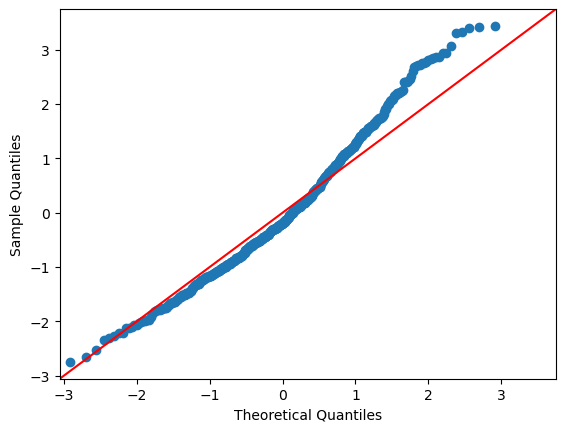

In [61]:
# generate QQ-plot from standardized residuals (outliers can be easily detected from standardized residuals than normal residuals)
fig = sm.qqplot(model_0.resid, line='45')
plt.show()

In [62]:
# Shapiro-Wilk test
# Null hypothesis: data is drawn from normal distribution
w, pvalue = stats.shapiro(model_0.resid)
print('Shapiro-Wilk test for residuals:', pvalue)

Shapiro-Wilk test for residuals: 1.635760958913234e-07


_Two-way ANOVA_

In [63]:
model_1 = ols('midpoint_h ~ C(location) * C(weekday)', data=df).fit()

In [64]:
anova_results = sm.stats.anova_lm(model_1, typ=3)

In [65]:
print("ANOVA Results:")
print(anova_results)

ANOVA Results:
                              sum_sq     df             F        PR(>F)
Intercept               71090.857907    1.0  98545.463270  0.000000e+00
C(location)                 0.000713    1.0      0.000989  9.749257e-01
C(weekday)                 29.125550    1.0     40.373558  4.342691e-10
C(location):C(weekday)      1.959224    1.0      2.715858  9.991545e-02
Residual                  404.706315  561.0           NaN           NaN


_Tukey's multiple comparison test_

In [66]:
# post-hoc test 
posthoc_midpoint = pairwise_tukeyhsd(
    endog=df['midpoint_h'],  
    groups=df['location'].astype(str) + '_' + df['weekday'].astype(str),  
    alpha=0.05  
)

In [67]:
print(posthoc_midpoint)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
ITA_free days ITA_work days  -0.6542    0.0 -0.9195 -0.3889   True
ITA_free days  UK_free days   0.0044    1.0 -0.3565  0.3653  False
ITA_free days  UK_work days  -0.9199    0.0 -1.2002 -0.6395   True
ITA_work days  UK_free days   0.6586    0.0  0.3427  0.9745   True
ITA_work days  UK_work days  -0.2657 0.0102 -0.4851 -0.0463   True
 UK_free days  UK_work days  -0.9243    0.0 -1.2529 -0.5957   True
------------------------------------------------------------------


_Assumption_

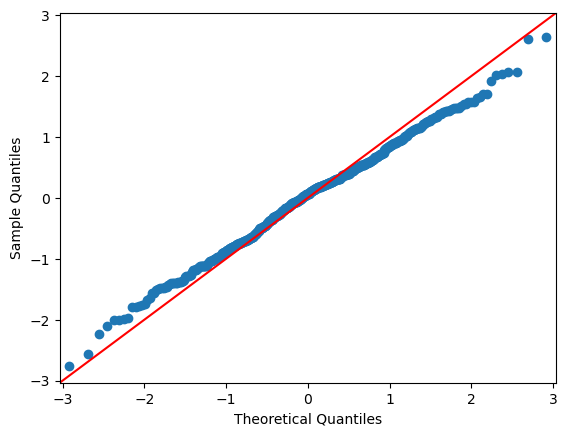

In [68]:
#  generate QQ-plot from standardized residuals (outliers can be easily detected from standardized residuals than normal residuals)
fig = sm.qqplot(model_1.resid, line='45')
plt.show()

In [69]:
#detecting outliers
outliers = model_1.get_influence()
outliers_summary = outliers.summary_frame()
outliers_summary = outliers_summary[outliers_summary['cooks_d'] > 4 / len(df)]
outliers_summary = outliers_summary.sort_values('cooks_d', ascending=False)
print(outliers_summary)

     dfb_Intercept  dfb_C(location)[T.UK]  dfb_C(weekday)[T.work days]  \
198  -8.214732e-14          -3.126047e-01                 1.499256e-13   
187  -8.192180e-14          -2.555151e-01                 1.495140e-13   
45    0.000000e+00           2.510254e-01                 2.058128e-13   
263  -8.190417e-14           2.505135e-01                 1.386498e-13   
333  -8.187567e-14          -2.422073e-01                 1.429328e-13   
16   -4.093184e-14          -2.386282e-01                 1.981279e-13   
219  -8.179554e-14          -2.171857e-01                 1.352206e-13   
66   -2.742842e-01           1.706517e-01                 2.321582e-01   
106  -4.088360e-14           2.076214e-01                 2.065455e-13   
332  -8.174691e-14           2.004927e-01                 1.427081e-13   
256   2.486142e-01          -1.546805e-01                -2.104307e-01   
166   2.465499e-01          -1.533962e-01                -2.086834e-01   
402  -2.448228e-01           1.523216e

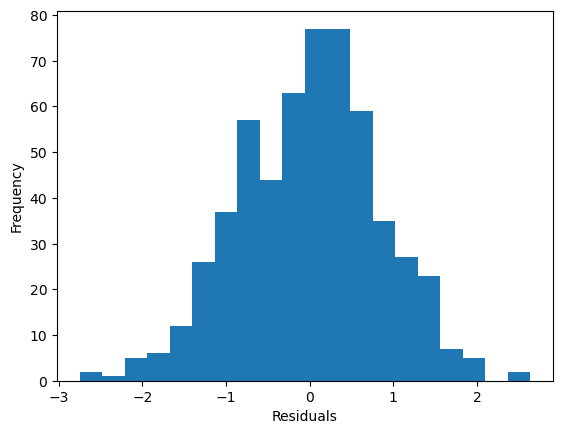

In [70]:
#frequency vs residuals
plt.hist(model_1.resid, bins=20)
plt.xlabel("Residuals")
plt.ylabel('Frequency')
plt.show()

In [71]:
# Shapiro-Wilk test 
# Null hypothesis: data is drawn from normal distribution
w, pvalue = stats.shapiro(model_1.resid) 
print(w, pvalue)

0.9971190627346128 0.42437742104857146


_Plot results_

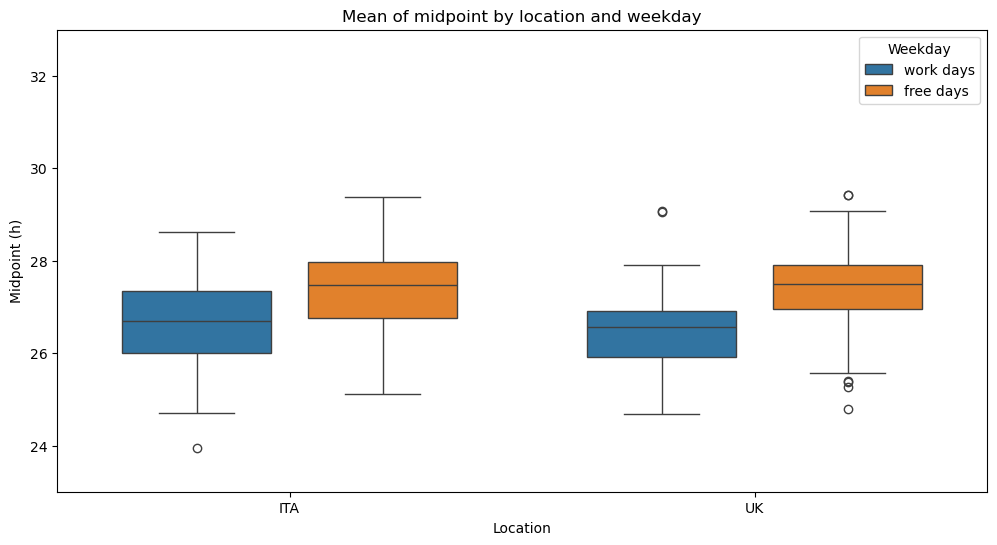

In [72]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='midpoint_h', hue='weekday', data=df, gap=0.2)
plt.title('Mean of midpoint by location and weekday')
plt.xlabel('Location')
plt.ylim(23, 33)
plt.ylabel('Midpoint (h)')
plt.legend(title='Weekday')
plt.show()

------------------------------------------------------------------------------------

_Two-way ANOVA_

In [73]:
model_2 = ols('sleep_duration ~ C(location) * C(weekday)', data=df).fit()

In [74]:
anova_results = sm.stats.anova_lm(model_2, typ=3)

In [75]:
print("ANOVA Results:")
print(anova_results)

ANOVA Results:
                             sum_sq     df            F         PR(>F)
Intercept               8091.479605    1.0  4919.756476  7.761513e-280
C(location)                0.414689    1.0     0.252138   6.157706e-01
C(weekday)                 9.393923    1.0     5.711664   1.718163e-02
C(location):C(weekday)     0.009030    1.0     0.005491   9.409583e-01
Residual                 922.671698  561.0          NaN            NaN


_Tukey's multiple comparison test_

In [76]:
# post-hoc test 
posthoc_midpoint = pairwise_tukeyhsd(
    endog=df['sleep_duration'],  
    groups=df['location'].astype(str) + '_' + df['weekday'].astype(str),  
    alpha=0.05  
)

In [77]:
print(posthoc_midpoint)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
    group1        group2    meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------
ITA_free days ITA_work days  -0.3715 0.0802 -0.7721  0.029  False
ITA_free days  UK_free days   0.1062 0.9586 -0.4387 0.6511  False
ITA_free days  UK_work days   -0.247 0.4361 -0.6703 0.1763  False
ITA_work days  UK_free days   0.4777 0.0495  0.0007 0.9547   True
ITA_work days  UK_work days   0.1245 0.7673 -0.2067 0.4558  False
 UK_free days  UK_work days  -0.3532 0.2585 -0.8494  0.143  False
-----------------------------------------------------------------


_Assumption_

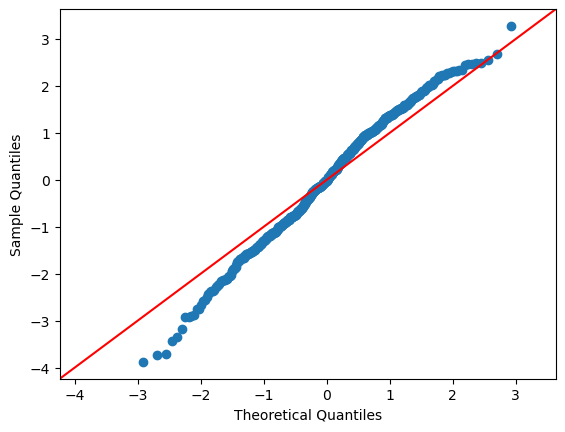

In [78]:
#  generate QQ-plot from standardized residuals (outliers can be easily detected from standardized residuals than normal residuals)
fig = sm.qqplot(model_2.resid, line='45')
plt.show()

In [79]:
#detecting outliers
outliers = model_2.get_influence()
outliers_summary = outliers.summary_frame()
outliers_summary = outliers_summary[outliers_summary['cooks_d'] > 4 / len(df)]
outliers_summary = outliers_summary.sort_values('cooks_d', ascending=False)
print(outliers_summary)

     dfb_Intercept  dfb_C(location)[T.UK]  dfb_C(weekday)[T.work days]  \
499  -3.159561e-01           1.965788e-01                 2.674299e-01   
540  -3.021677e-01           1.880000e-01                 2.557592e-01   
235  -2.706250e-14          -1.922622e-01                 3.435914e-14   
395  -4.059106e-14          -1.902414e-01                 3.220957e-14   
403  -2.370374e-01           1.474778e-01                 2.006320e-01   
31   -2.370374e-01           1.474778e-01                 2.006320e-01   
396  -4.058320e-14          -1.841815e-01                 3.220333e-14   
174  -2.227123e-01           1.385652e-01                 1.885070e-01   
263  -2.704442e-14          -1.707273e-01                 3.075951e-14   
459   2.172971e-01          -1.351960e-01                -1.839235e-01   
424  -5.407844e-14          -1.640063e-01                 4.541519e-14   
431  -1.975274e-01           1.228958e-01                 1.671901e-01   
270  -2.703160e-14           1.536408e

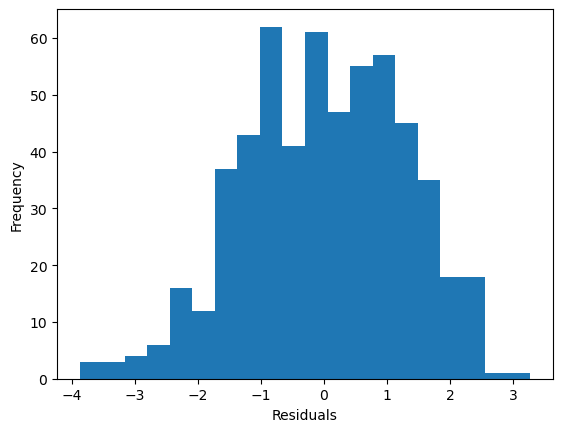

In [80]:
#frequency vs residuals
plt.hist(model_2.resid, bins=20)
plt.xlabel("Residuals")
plt.ylabel('Frequency')
plt.show()

In [81]:
# Shapiro-Wilk test 
# Null hypothesis: data is drawn from normal distribution
w, pvalue = stats.shapiro(model_2.resid) 
print(w, pvalue)

0.9912014605336796 0.001931062288490526


_Plot results_

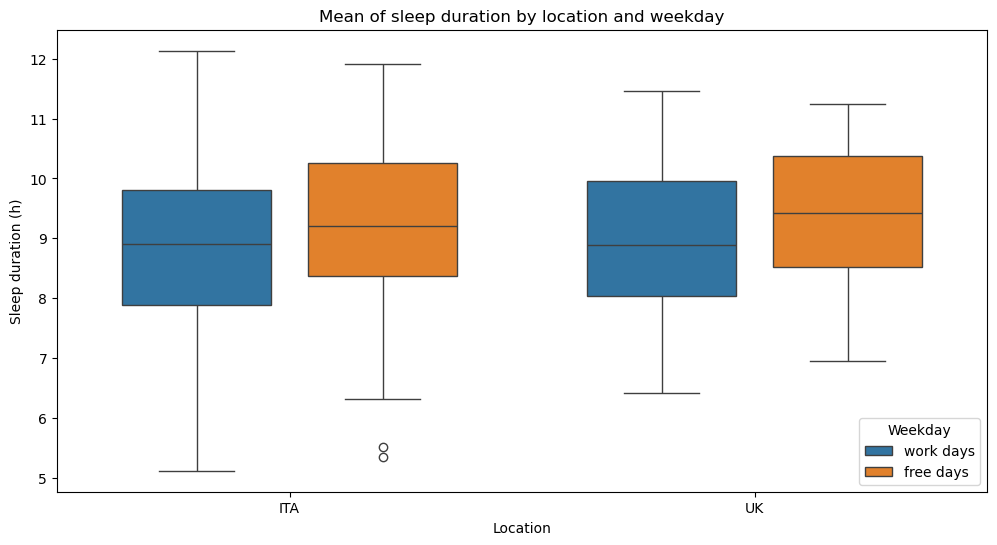

In [82]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='sleep_duration', hue='weekday', data=df, gap=0.2)
plt.title('Mean of sleep duration by location and weekday')
plt.xlabel('Location')
plt.ylim()
plt.ylabel('Sleep duration (h)')
plt.legend(title='Weekday')
plt.show()

------------------------------------------------------

_Two way ANOVA_

In [83]:
model_3 = ols('phase ~ C(location) * C(weekday)', data=df).fit()

In [84]:
anova_results = sm.stats.anova_lm(model_3, typ=3)

In [85]:
print("ANOVA Results:")
print(anova_results)

ANOVA Results:
                            sum_sq     df          F        PR(>F)
Intercept                 5.400237    1.0   3.586256  5.877359e-02
C(location)              32.988797    1.0  21.907605  3.591110e-06
C(weekday)               61.085467    1.0  40.566386  3.960816e-10
C(location):C(weekday)    0.071979    1.0   0.047800  8.270153e-01
Residual                844.762137  561.0        NaN           NaN


_Tukey's multiple comparison test_

In [86]:
# post-hoc test 
posthoc_midpoint = pairwise_tukeyhsd(
    endog=df['phase'],  
    groups=df['location'].astype(str) + '_' + df['weekday'].astype(str),  
    alpha=0.05  
)

In [87]:
print(posthoc_midpoint)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
ITA_free days ITA_work days  -0.9474    0.0 -1.3307 -0.5641   True
ITA_free days  UK_free days   0.9471    0.0  0.4257  1.4686   True
ITA_free days  UK_work days   0.0515 0.9878 -0.3535  0.4566  False
ITA_work days  UK_free days   1.8945    0.0  1.4381  2.3509   True
ITA_work days  UK_work days   0.9989    0.0  0.6819  1.3159   True
 UK_free days  UK_work days  -0.8956    0.0 -1.3704 -0.4208   True
------------------------------------------------------------------


_Assumption_

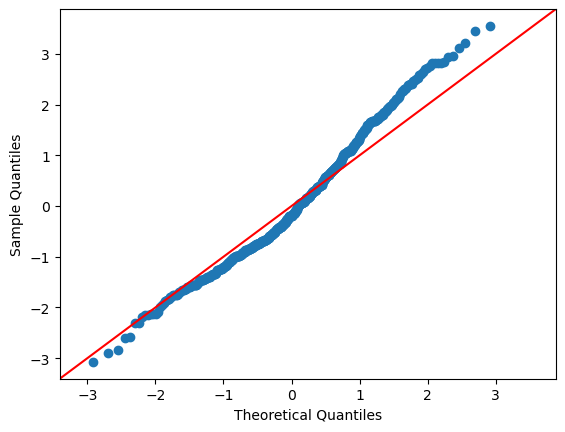

In [88]:
#  generate QQ-plot from standardized residuals (outliers can be easily detected from standardized residuals than normal residuals)
fig = sm.qqplot(model_3.resid, line='45')
plt.show()

In [89]:
#detecting outliers
outliers = model_3.get_influence()
outliers_summary = outliers.summary_frame()
outliers_summary = outliers_summary[outliers_summary['cooks_d'] > 4 / len(df)]
outliers_summary = outliers_summary.sort_values('cooks_d', ascending=False)
print(outliers_summary)

     dfb_Intercept  dfb_C(location)[T.UK]  dfb_C(weekday)[T.work days]  \
235  -3.099416e-15          -2.441125e-01                 7.495405e-16   
533  -2.433562e-15           2.267584e-01                 1.498038e-15   
480  -2.654364e-15           2.225196e-01                 1.497795e-15   
333  -3.096390e-15          -2.193654e-01                 1.497617e-15   
16   -1.548073e-15          -2.172475e-01                 1.497499e-15   
487   2.728196e-01          -1.697404e-01                -2.309185e-01   
514   2.499182e-01          -1.554919e-01                -2.115344e-01   
507  -2.651641e-15           1.936071e-01                 7.481294e-16   
66   -2.407913e-01           1.498133e-01                 2.038093e-01   
521   2.399197e-01          -1.492711e-01                -2.030716e-01   
527  -2.429373e-15           1.767219e-01                 1.495460e-15   
216   4.438696e-16          -2.761628e-15                 3.005582e-15   
459   2.192459e-01          -1.364085e

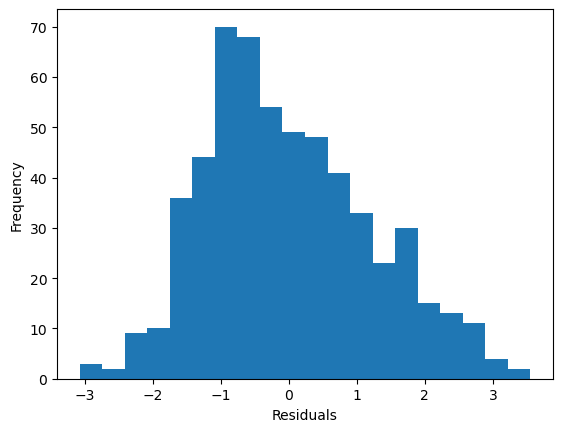

In [90]:
#frequency vs residuals
plt.hist(model_3.resid, bins=20)
plt.xlabel("Residuals")
plt.ylabel('Frequency')
plt.show()

In [91]:
# Shapiro-Wilk test 
# Null hypothesis: data is drawn from normal distribution
w, pvalue = stats.shapiro(model_3.resid) 
print(w, pvalue)

0.9797411194220492 4.6713664046038e-07


_Plot results_

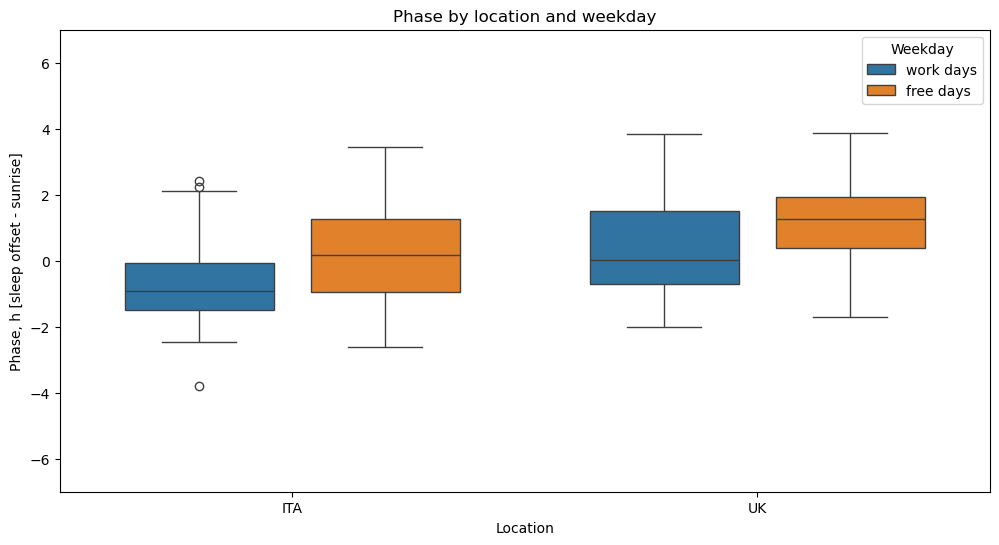

In [92]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='phase', hue='weekday', data=df, gap=0.2)
plt.title('Phase by location and weekday')
plt.xlabel('Location')
plt.ylim(-7,7)
plt.ylabel('Phase, h [sleep offset - sunrise]')
plt.legend(title='Weekday')

plt.show()

----------------------------------------------------------------------------------

In [93]:
#create a report with the results of the analyses the plots and the tables from the descriptive statistics and the ANOVA